In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..', 'lime_ndt')))
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(""), '..')))

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lime_ndt.lime_tabular import LimeTabularExplainer
from lime_ndt.utils.ndt_sklearn_wrapper import NDTRegressorWrapper

# Charger le dataset diabetes
housing = fetch_california_housing()
X = housing.data
y = housing.target  # Cible de régression

# Séparer en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Entraîner le modèle global Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Fonction de prédiction globale utilisant le Random Forest
def predict_fn(X):
    return rf.predict(X)

# Créer l'explainer LIME
explainer = LimeTabularExplainer(
    X_train,
    feature_names=housing.feature_names,
    class_names=None,
    discretize_continuous=True,
    mode='regression',    
)

# Créer le modèle local NDT
model_regressor = NDTRegressorWrapper(D=X_train.shape[1])

# Expliquer une instance
exp = explainer.explain_instance(
    X_test[1],
    predict_fn,
    num_features=8,
    model_regressor=model_regressor
)

print("Explication locale (feature, poids):")
print(exp.as_list())

mean_leaf_values shape: (32, 1, 1)
self.L: 32 self.C: 1
mean_leaf_values shape after squeeze: (32, 1)



c:\Users\DELL\Desktop\lime_ndt\.venv\lib\site-packages\keras\src\optimizers\base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Explication locale (feature, poids):
[('MedInc <= 2.57', -8.030129661535243), ('34.27 < Latitude <= 37.72', -3.57507694864089), ('-121.80 < Longitude <= -118.51', 0.6958426664143134), ('29.00 < HouseAge <= 37.00', -0.13550522476373827), ('2.43 < AveOccup <= 2.82', -0.103990240478669), ('1167.00 < Population <= 1727.00', -0.10040073996510568), ('4.45 < AveRooms <= 5.23', -0.04817747788367521), ('AveBedrms > 1.10', -0.012240175454658608)]


In [3]:
from lime.lime_tabular import LimeTabularExplainer

# Créer l'explainer LIME officiel
explainer_lime = LimeTabularExplainer(
    X_train,
    feature_names=housing.feature_names,
    class_names=None,
    discretize_continuous=True,
    mode='regression',
)

# Expliquer une instance avec le modèle local Ridge par défaut de LIME
exp_ridge = explainer_lime.explain_instance(
    X_test[1],
    predict_fn,
    num_features=8
)

print("\nExplication locale avec Ridge (LIME officiel) (feature, poids):")
print(exp_ridge.as_list())


Explication locale avec Ridge (LIME officiel) (feature, poids):
[('MedInc <= 2.57', -0.9091564106027101), ('34.27 < Latitude <= 37.72', -0.23215622950339987), ('-121.80 < Longitude <= -118.51', 0.11523153573541382), ('AveBedrms > 1.10', 0.11477297556391698), ('4.45 < AveRooms <= 5.23', -0.09752289785237918), ('29.00 < HouseAge <= 37.00', 0.06371622973706881), ('2.43 < AveOccup <= 2.82', 0.014192360166978026), ('1167.00 < Population <= 1727.00', -0.014129255644696548)]


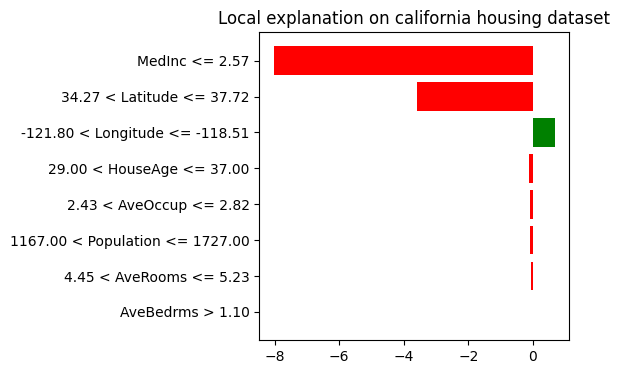

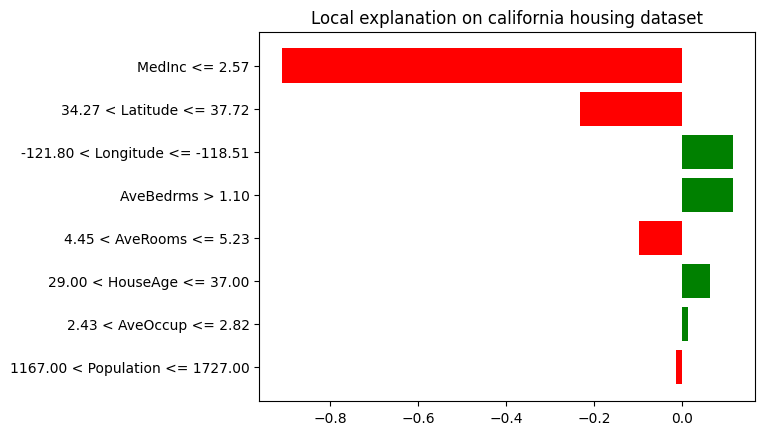

In [4]:
import matplotlib.pyplot as plt

fig = exp.as_pyplot_figure()
fig.axes[0].set_title("Local explanation on california housing dataset")
plt.show()

fig_ridge = exp_ridge.as_pyplot_figure()
fig_ridge.axes[0].set_title("Local explanation on california housing dataset")
plt.show()


Local explanation with DecisionTreeRegressor surrogate (feature, weight):
[('MedInc <= 2.57', -0.5743796453280593), ('AveOccup > 3.28', -0.14792288789453056), ('34.27 < Latitude <= 37.72', -0.09984192983909508), ('-121.80 < Longitude <= -118.51', 0.04846772222338048), ('1.01 < AveBedrms <= 1.05', -0.04223424766573938), ('1167.00 < Population <= 1727.00', -0.03308932768049389), ('18.00 < HouseAge <= 29.00', -0.032928717936464694), ('AveRooms <= 4.45', -0.02113552143223662)]


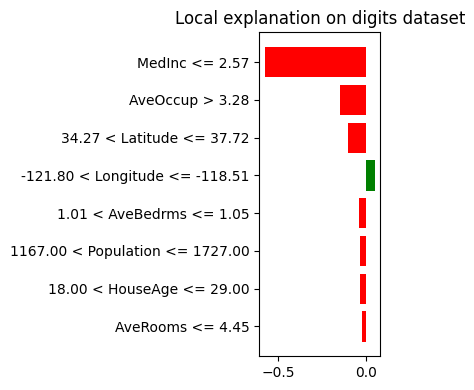

In [5]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import matplotlib.pyplot as plt

# --- Custom wrapper class ---
class SignedDecisionTreeRegressorWrapper(DecisionTreeRegressor):
    """
    DecisionTreeRegressor wrapper for LIME that produces signed coefficients
    based on local feature–target correlations.
    """
    def fit(self, X, y, sample_weight=None):
        super().fit(X, y, sample_weight=sample_weight)
        importances = np.array(self.feature_importances_)
        
        # Compute correlation signs between X_j and y
        signs = np.zeros_like(importances)
        for j in range(X.shape[1]):
            corr = np.corrcoef(X[:, j], y)[0, 1]
            signs[j] = np.sign(corr) if not np.isnan(corr) else 0
        
        # Combine magnitude (importance) with direction (sign)
        signed_importances = importances * signs
        
        # Normalize
        if np.sum(np.abs(signed_importances)) > 0:
            signed_importances = signed_importances / np.sum(np.abs(signed_importances))
        
        self.coef_ = signed_importances
        self.intercept_ = np.array([np.mean(y)])
        return self

# --- Instantiate and use in LIME ---
local_dt = SignedDecisionTreeRegressorWrapper(max_depth=8, random_state=0)

exp_dt = explainer.explain_instance(
    X_test[0],
    predict_fn,
    num_features=8,
    model_regressor=local_dt
)

print("\nLocal explanation with DecisionTreeRegressor surrogate (feature, weight):")
print(exp_dt.as_list())

fig_dt = exp_dt.as_pyplot_figure()
fig_dt.axes[0].set_title("Local explanation on digits dataset")
plt.tight_layout()
plt.show()
